In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [49]:
df = pd.read_csv('housing_data.csv')

In [50]:
df

,Price,LivingArea,Bathrooms,Bedrooms,LotSize,Age,Fireplace
0,16858,1629,1.0,3,0.76,180,0
1,26049,1344,2.0,3,0.92,13,0
2,26130,822,1.0,2,0.56,173,0
3,31113,1540,1.0,2,0.04,115,0
4,40932,1320,1.0,3,0.17,90,0
...,...,...,...,...,...,...,...
1042,387652,3504,2.5,5,0.90,0,1
1043,391842,3003,3.5,4,0.46,88,1
1044,394532,3361,3.5,4,0.71,1,1
1045,432845,3250,2.5,3,0.53,23,1


In [51]:
## target is price
## features remaining all columns

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1047 entries, 0 to 1046
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Price       1047 non-null   int64  
 1   LivingArea  1047 non-null   int64  
 2   Bathrooms   1047 non-null   float64
 3   Bedrooms    1047 non-null   int64  
 4   LotSize     1047 non-null   float64
 5   Age         1047 non-null   int64  
 6   Fireplace   1047 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 57.4 KB


In [53]:
### duplicates
df.duplicated().sum().sum()

np.int64(12)

In [54]:
df.drop_duplicates(inplace = True, ignore_index = True)

In [55]:
df

,Price,LivingArea,Bathrooms,Bedrooms,LotSize,Age,Fireplace
0,16858,1629,1.0,3,0.76,180,0
1,26049,1344,2.0,3,0.92,13,0
2,26130,822,1.0,2,0.56,173,0
3,31113,1540,1.0,2,0.04,115,0
4,40932,1320,1.0,3,0.17,90,0
...,...,...,...,...,...,...,...
1030,387652,3504,2.5,5,0.90,0,1
1031,391842,3003,3.5,4,0.46,88,1
1032,394532,3361,3.5,4,0.71,1,1
1033,432845,3250,2.5,3,0.53,23,1


In [56]:
df.duplicated().sum()

np.int64(0)

In [57]:
## missing valuew
df.isnull().sum()

Price         0
LivingArea    0
Bathrooms     0
Bedrooms      0
LotSize       0
Age           0
Fireplace     0
dtype: int64

In [58]:
## outlier check

target = df[['Price']]
target

,Price
0,16858
1,26049
2,26130
3,31113
4,40932
...,...
1030,387652
1031,391842
1032,394532
1033,432845


In [59]:
features = df.drop(columns = 'Price')
features

,LivingArea,Bathrooms,Bedrooms,LotSize,Age,Fireplace
0,1629,1.0,3,0.76,180,0
1,1344,2.0,3,0.92,13,0
2,822,1.0,2,0.56,173,0
3,1540,1.0,2,0.04,115,0
4,1320,1.0,3,0.17,90,0
...,...,...,...,...,...,...
1030,3504,2.5,5,0.90,0,1
1031,3003,3.5,4,0.46,88,1
1032,3361,3.5,4,0.71,1,1
1033,3250,2.5,3,0.53,23,1


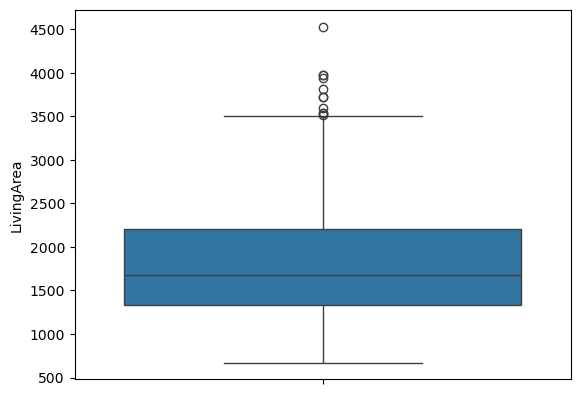

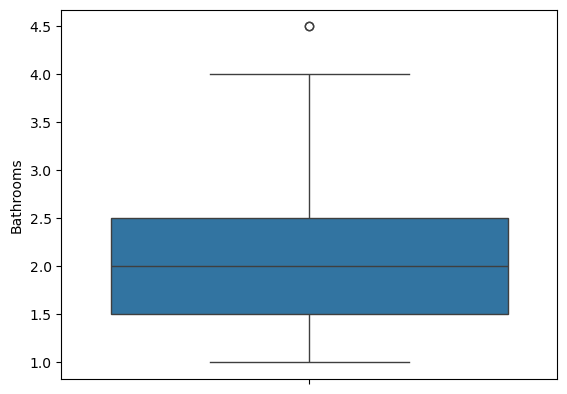

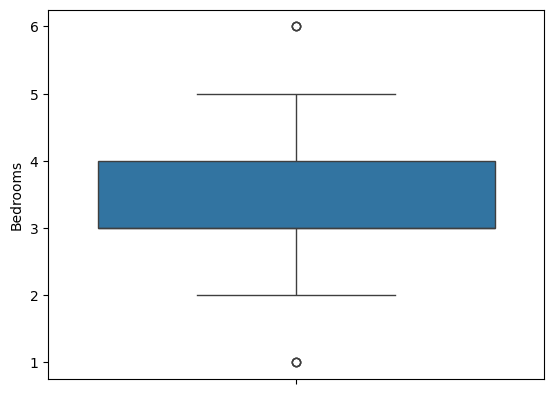

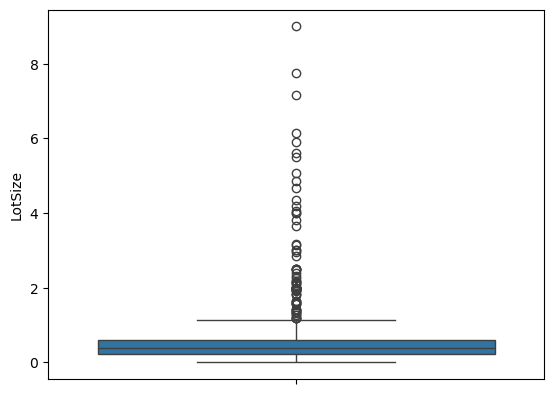

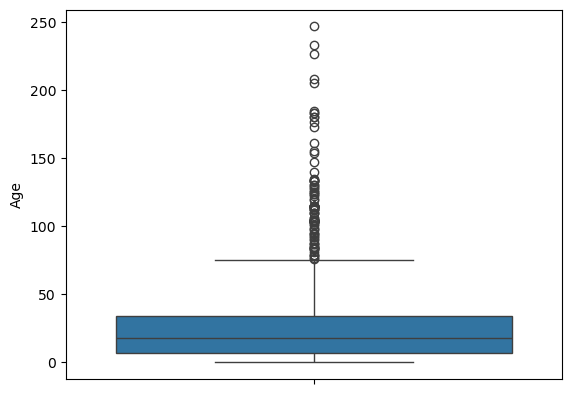

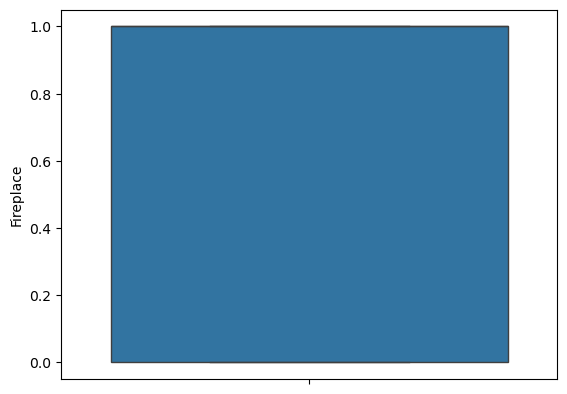

In [60]:
for col in features.columns:
    sns.boxplot(data = features , y = col)
    plt.show()

In [61]:
## outlier capping
def outlier_capping(df,column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    IQR = q3 - q1
    lower_extreme = q1-1.5*IQR
    upper_extreme = q3+1.5*IQR
    df[column] = df[column].apply(lambda x : lower_extreme if x < lower_extreme else upper_extreme if x > upper_extreme else x)
for col in features.select_dtypes(include = ['int','float']).columns:
        outlier_capping(features,col)

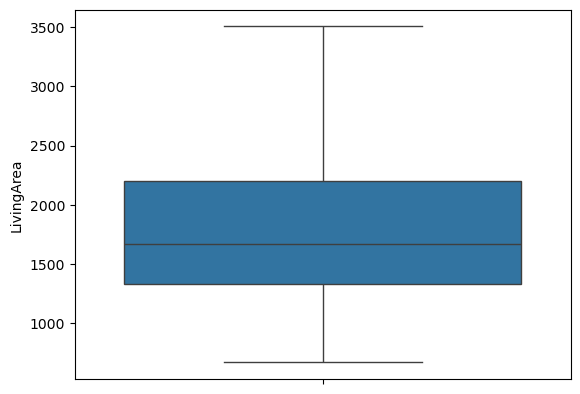

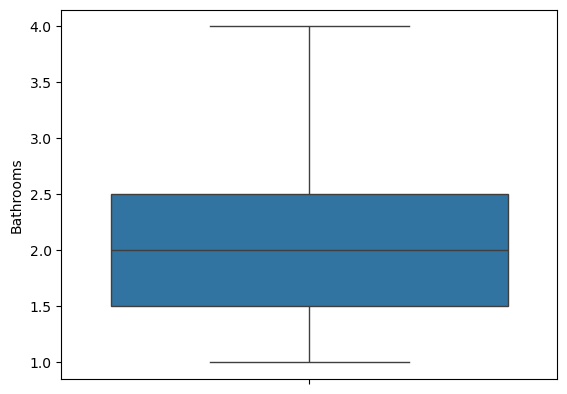

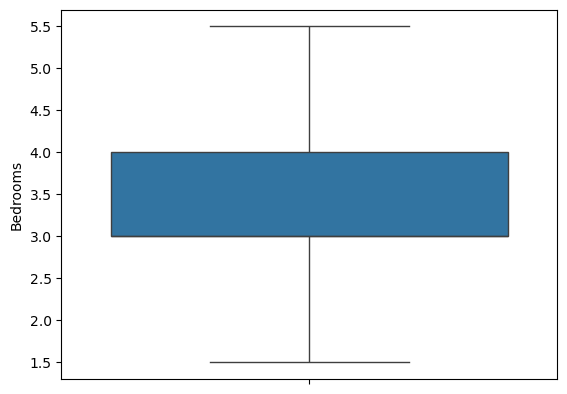

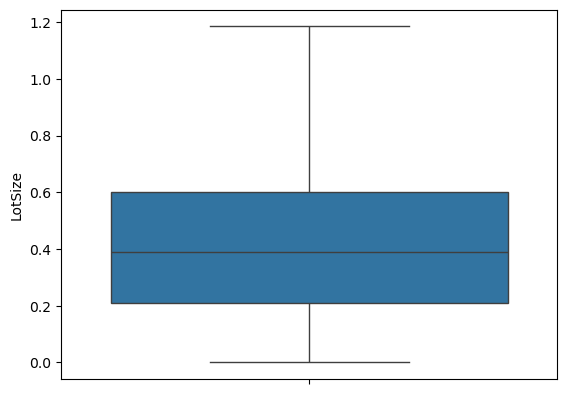

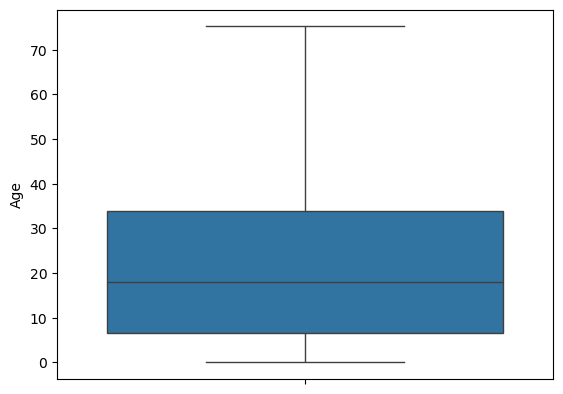

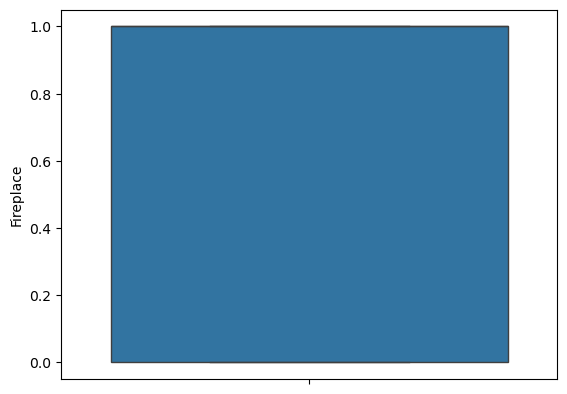

In [62]:
for col in features.columns:
    sns.boxplot(data = features , y = col)
    plt.show()

<Axes: >

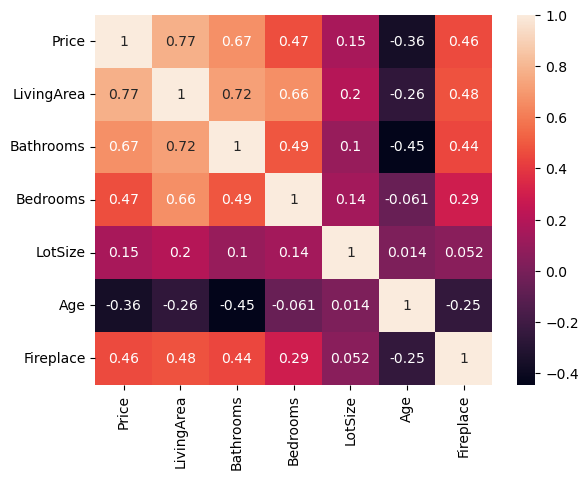

In [63]:
## correlation
corr = df.corr()
sns.heatmap(corr,annot = True)

In [64]:
df1 = pd.concat([features,target], axis = 1)
df.head()

,Price,LivingArea,Bathrooms,Bedrooms,LotSize,Age,Fireplace
0,16858,1629,1.0,3,0.76,180,0
1,26049,1344,2.0,3,0.92,13,0
2,26130,822,1.0,2,0.56,173,0
3,31113,1540,1.0,2,0.04,115,0
4,40932,1320,1.0,3,0.17,90,0


<Axes: >

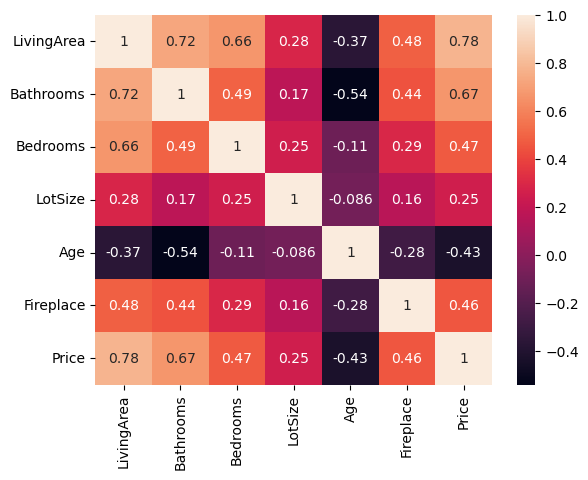

In [66]:
new_corr = df1.corr()
sns.heatmap(new_corr,annot = True)

In [68]:
from sklearn.feature_selection import f_regression

<Axes: >

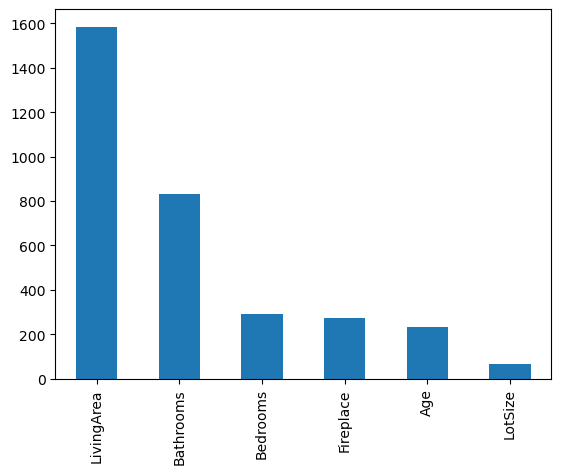

In [74]:
f_reg = f_regression(features,target)
pd.Series(f_reg[0],index = features.columns).sort_values(ascending = False).plot(kind = 'bar')

In [76]:
## check multicolinarity 
## VIF - varience inflation factor

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [79]:
vif = pd.DataFrame()
vif['Features'] = features.columns
vif['vif__score'] = [variance_inflation_factor(features.values,i) for i in range(len(features.columns))]

In [80]:
vif

,Features,vif__score
0,LivingArea,28.393716
1,Bathrooms,21.617158
2,Bedrooms,29.100456
3,LotSize,3.345417
4,Age,2.471556
5,Fireplace,3.304989
